<a href="https://colab.research.google.com/github/bingjunw/ust-deep-learning-2026/blob/main/VGG_vs_No_VGG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping

# Data preparation
dataset_path = kagglehub.dataset_download("ikarus777/best-artworks-of-all-time")
images_dir = os.path.join(dataset_path, "images", "images")

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    horizontal_flip=True
)

train_generator = datagen.flow_from_directory(
    images_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    images_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

num_classes = train_generator.num_classes
label_map = {v: k for k, v in train_generator.class_indices.items()}

100%|██████████| 2.29G/2.29G [00:18<00:00, 134MB/s]

Extracting files...


Found 7042 images belonging to 51 classes.
Found 1732 images belonging to 51 classes.


In [2]:
# Build the model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model.compile(optimizer=optimizers.Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
history_initial = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=[early_stop]
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 80s 324ms/step - accuracy: 0.0879 - loss: 3.7530 - val_accuracy: 0.1484 - val_loss: 3.4814
Epoch 2/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 61s 278ms/step - accuracy: 0.1373 - loss: 3.4706 - val_accuracy: 0.1744 - val_loss: 3.3140
Epoch 3/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 61s 275ms/step - accuracy: 0.1741 - loss: 3.2936 - val_accuracy: 0.2050 - val_loss: 3.1733
Epoch 4/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 61s 278ms/step - accuracy: 0.2055 - loss: 3.1592 - val_accuracy: 0.2304 - val_loss: 3.0577
Epoch 5/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 62s 278ms/step - accuracy: 0.2312 - loss: 3.0339 - val_accuracy: 0.2691 - val_loss: 2.9551
Epoch 6/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 62s 281ms/step - accuracy: 0.2531 - loss: 2.9366 - val_accuracy: 0.2812 - val_loss: 2.8699
Epoch 7/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 62s 278ms/step - accuracy: 0.2675 - loss: 2.8522 - val_accuracy: 0.2812 - val_loss: 2.8012
Epoch 8/10
221/221 ━━━━━━━━━━━━━

In [3]:
# Fine tune
base_model.trainable = True
for layer in base_model.layers[:-4]:
    layer.trainable = False

model.compile(optimizer=optimizers.Adam(1e-6), loss='categorical_crossentropy', metrics=['accuracy'])
history_finetune = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=[early_stop]
)

Epoch 1/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 72s 303ms/step - accuracy: 0.3253 - loss: 2.5551 - val_accuracy: 0.3274 - val_loss: 2.5285
Epoch 2/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 62s 280ms/step - accuracy: 0.3347 - loss: 2.4902 - val_accuracy: 0.3424 - val_loss: 2.4798
Epoch 3/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 63s 286ms/step - accuracy: 0.3428 - loss: 2.4609 - val_accuracy: 0.3418 - val_loss: 2.4442
Epoch 4/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 62s 280ms/step - accuracy: 0.3580 - loss: 2.4066 - val_accuracy: 0.3505 - val_loss: 2.4103
Epoch 5/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 62s 279ms/step - accuracy: 0.3523 - loss: 2.3830 - val_accuracy: 0.3614 - val_loss: 2.3829
Epoch 6/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 62s 280ms/step - accuracy: 0.3644 - loss: 2.3482 - val_accuracy: 0.3712 - val_loss: 2.3597
Epoch 7/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 71s 319ms/step - accuracy: 0.3671 - loss: 2.3305 - val_accuracy: 0.3707 - val_loss: 2.3487
Epoch 8/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 61s 277ms/step - accuracy: 0.3837 - loss: 2

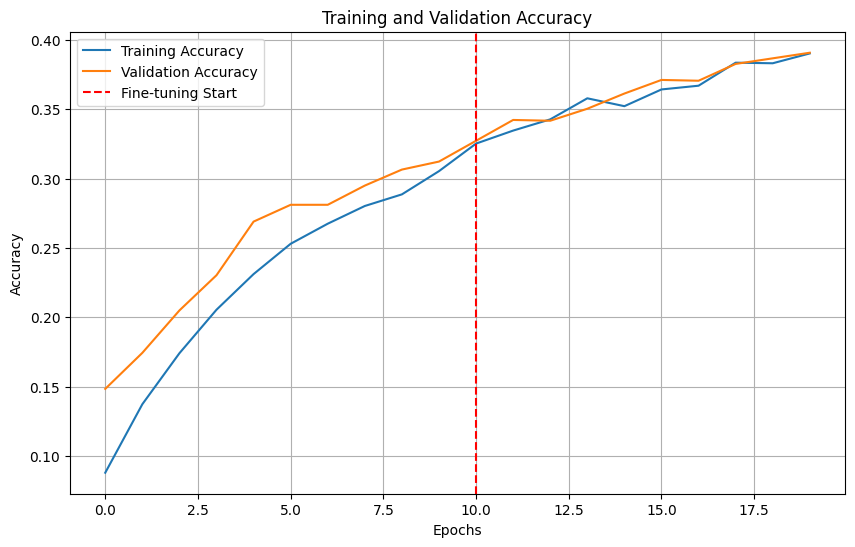

In [4]:
# Visualize the accuracy curve
acc = history_initial.history['accuracy'] + history_finetune.history['accuracy']
val_acc = history_initial.history['val_accuracy'] + history_finetune.history['val_accuracy']

plt.figure(figsize=(10, 6))
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(x=10, color='r', linestyle='--', label='Fine-tuning Start')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
original_loss, original_acc = model.evaluate(val_generator)
print(f"Original Accuracy: {original_acc}")

# Scramble
y_true = val_generator.classes
y_scrambled = np.random.permutation(y_true)

# Get the acc after scramble
y_pred_probs = model.predict(val_generator)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

scrambled_acc = np.mean(y_pred_labels == y_scrambled)
print(f"Scrambled (Random) Accuracy: {scrambled_acc}")

55/55 ━━━━━━━━━━━━━━━━━━━━ 12s 211ms/step - accuracy: 0.3897 - loss: 2.2869
Original Accuracy: 0.3897228538990021
55/55 ━━━━━━━━━━━━━━━━━━━━ 13s 217ms/step
Scrambled (Random) Accuracy: 0.04561200923787529


In [10]:
# Run the no VGG model to see the difference
def build_no_vgg_model(input_shape=(128, 128, 3), num_classes=50):
    model = models.Sequential([

        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

no_vgg_model = build_no_vgg_model(num_classes=num_classes)
history_no_vgg = no_vgg_model.fit(train_generator, validation_data=val_generator, epochs=20)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 71s 306ms/step - accuracy: 0.1386 - loss: 3.5135 - val_accuracy: 0.1894 - val_loss: 3.2087
Epoch 2/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 60s 271ms/step - accuracy: 0.1941 - loss: 3.1520 - val_accuracy: 0.2096 - val_loss: 2.9715
Epoch 3/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 59s 265ms/step - accuracy: 0.2336 - loss: 2.9408 - val_accuracy: 0.2569 - val_loss: 2.8126
Epoch 4/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 68s 308ms/step - accuracy: 0.2562 - loss: 2.7777 - val_accuracy: 0.2754 - val_loss: 2.6846
Epoch 5/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 59s 267ms/step - accuracy: 0.2901 - loss: 2.6056 - val_accuracy: 0.2806 - val_loss: 2.6040
Epoch 6/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 58s 265ms/step - accuracy: 0.3259 - loss: 2.4744 - val_accuracy: 0.2950 - val_loss: 2.5761
Epoch 7/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 57s 260ms/step - accuracy: 0.3539 - loss: 2.3636 - val_accuracy: 0.3199 - val_loss: 2.4975
Epoch 8/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 58s 265ms/step - accuracy: 0.3868 - loss: 2

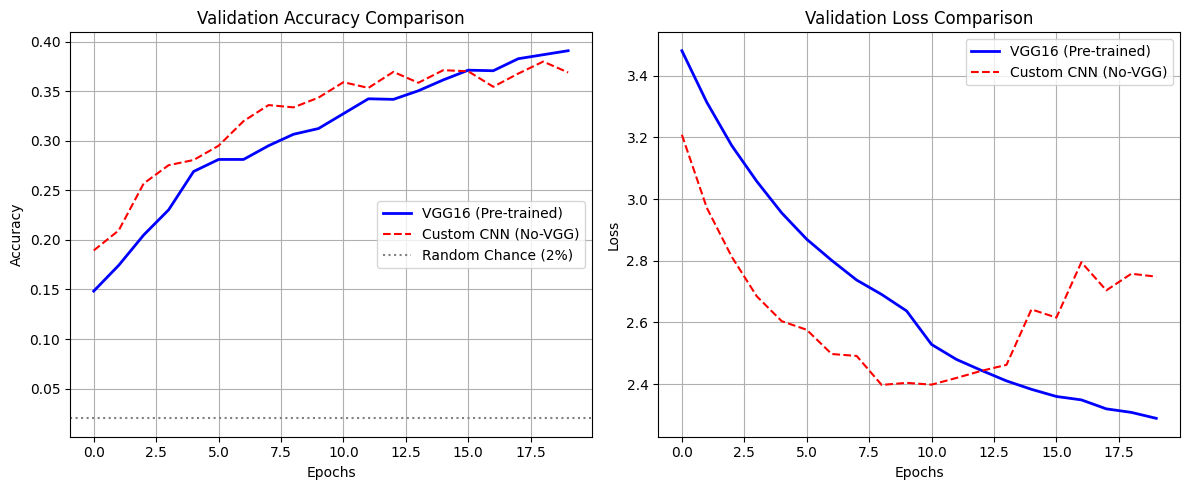

In [15]:
import matplotlib.pyplot as plt

def plot_comparison(history_vgg, history_no_vgg):
    plt.figure(figsize=(12, 5))

    # Acc
    plt.subplot(1, 2, 1)
    plt.plot(history_vgg.history['val_accuracy'], label='VGG16 (Pre-trained)', color='blue', linewidth=2)
    plt.plot(history_no_vgg.history['val_accuracy'], label='Custom CNN (No-VGG)', color='red', linestyle='--')
    plt.axhline(y=0.02, color='gray', linestyle=':', label='Random Chance (2%)')
    plt.title('Validation Accuracy Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history_vgg.history['val_loss'], label='VGG16 (Pre-trained)', color='blue', linewidth=2)
    plt.plot(history_no_vgg.history['val_loss'], label='Custom CNN (No-VGG)', color='red', linestyle='--')
    plt.title('Validation Loss Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Combine history for VGG model from history_initial and history_finetune
val_accuracy_vgg_combined = history_initial.history['val_accuracy'] + history_finetune.history['val_accuracy']
val_loss_vgg_combined = history_initial.history['val_loss'] + history_finetune.history['val_loss']

# Create a wrapper class to match the expected structure by plot_comparison
class HistoryWrapper:
    def __init__(self, val_acc, val_loss):
        self.history = {'val_accuracy': val_acc, 'val_loss': val_loss}

history_vgg = HistoryWrapper(val_accuracy_vgg_combined, val_loss_vgg_combined)

plot_comparison(history_vgg, history_no_vgg)